# Hedonic Pricing

We often try to predict the price of an asset from its observable characteristics. This is generally called **hedonic pricing**: How do the unit's characteristics determine its market price?

In the lab folder, there are three options: housing prices in pierce_county_house_sales.csv, car prices in cars_hw.csv, and airbnb rental prices in airbnb_hw.csv. If you know of another suitable dataset, please feel free to use that one.

1. Clean the data and perform some EDA and visualization to get to know the data set.
2. Transform your variables --- particularly categorical ones --- for use in your regression analysis.
3. Implement an ~80/~20 train-test split. Put the test data aside.
4. Build some simple linear models that include no transformations or interactions. Fit them, and determine their RMSE and $R^2$ on the both the training and test sets. Which of your models does the best?
5. Make partial correlation plots for each of the numeric variables in your model. Do you notice any significant non-linearities?
6. Include transformations and interactions of your variables, and build a more complex model that reflects your ideas about how the features of the asset determine its value. Determine its RMSE and $R^2$ on the training and test sets. How does the more complex model your build compare to the simpler ones?
7. Summarize your results from 1 to 6. Have you learned anything about overfitting and underfitting, or model selection?
8. If you have time, use the sklearn.linear_model.Lasso to regularize your model and select the most predictive features. Which does it select? What are the RMSE and $R^2$? We'll cover the Lasso later in detail in class.

In [2]:
!git clone https://github.com/ciara-graves/linear_models.git

fatal: destination path 'linear_models' already exists and is not an empty directory.


In [41]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

df=pd.read_csv('/content/linear_models/lab/data/pierce_county_house_sales.csv')
df.head()

,sale_date,sale_price,house_square_feet,attic_finished_square_feet,basement_square_feet,attached_garage_square_feet,detached_garage_square_feet,fireplaces,hvac_description,exterior,interior,stories,roof_cover,year_built,bedrooms,bathrooms,waterfront_type,view_quality,utility_sewer
0,2020-01-02,380000,2157,0,0,528,0,0,Warm and Cool Air Zone,Frame Siding,Drywall,2,Composition Shingle,1993,3,3,NaN,NaN,SEWER/SEPTIC INSTALLED
1,2020-01-02,383000,2238,0,0,396,0,0,Forced Air,Frame Siding,Drywall,2,Composition Shingle,2017,4,3,NaN,NaN,SEWER/SEPTIC INSTALLED
2,2020-01-01,419900,1452,0,0,0,0,1,Forced Air,Frame Siding,Drywall,1,Built Up Rock,1965,3,2,NaN,NaN,SEWER/SEPTIC INSTALLED
3,2020-01-02,251660,832,0,0,0,0,0,Forced Air,Frame Vinyl,Drywall,1,Composition Shingle,1919,2,1,NaN,NaN,SEWER/SEPTIC INSTALLED
4,2020-01-02,500000,1780,0,384,484,0,1,Forced Air,Frame Siding,Drywall,1,Composition Shingle,1955,3,2,NaN,NaN,SEWER/SEPTIC INSTALLED


    sale_date  sale_price  house_square_feet  attic_finished_square_feet  \
0  2020-01-02      380000               2157                           0   
1  2020-01-02      383000               2238                           0   
2  2020-01-01      419900               1452                           0   
3  2020-01-02      251660                832                           0   
4  2020-01-02      500000               1780                           0   

   basement_square_feet  attached_garage_square_feet  \
0                     0                          528   
1                     0                          396   
2                     0                            0   
3                     0                            0   
4                   384                          484   

   detached_garage_square_feet  fireplaces        hvac_description  \
0                            0           0  Warm and Cool Air Zone   
1                            0           0              Forced Air

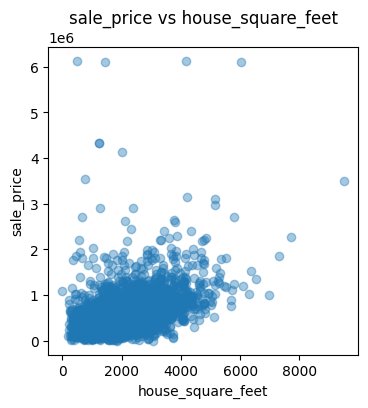

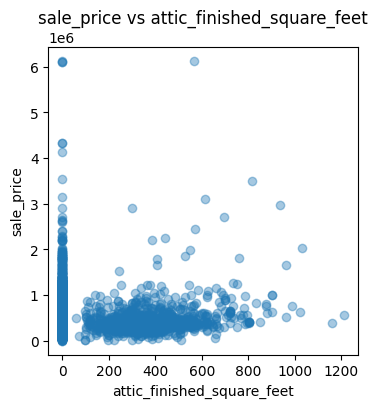

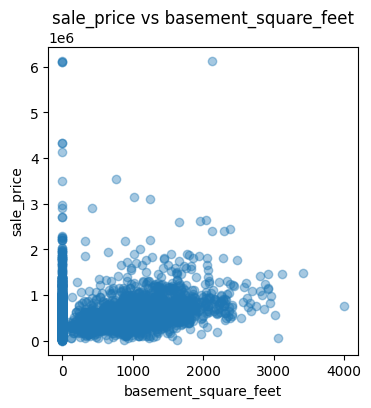

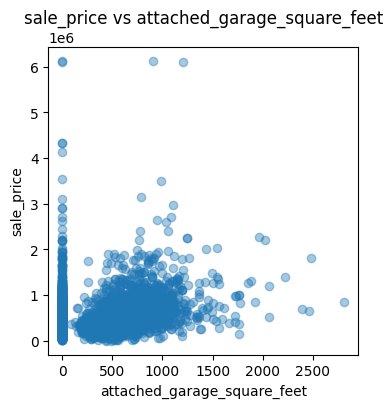

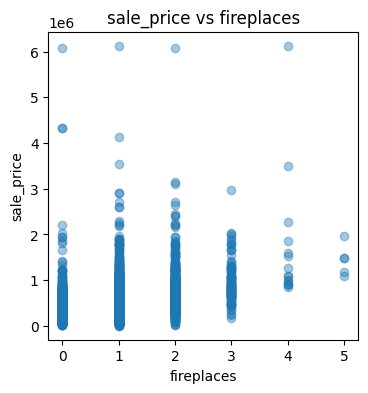

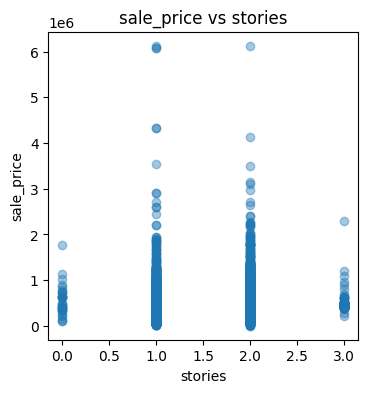

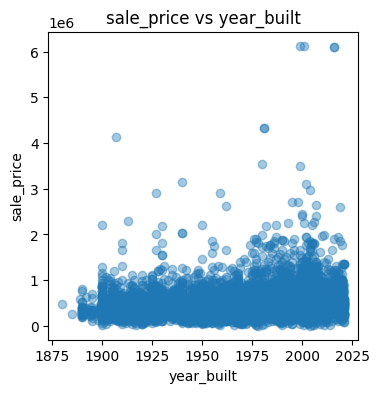

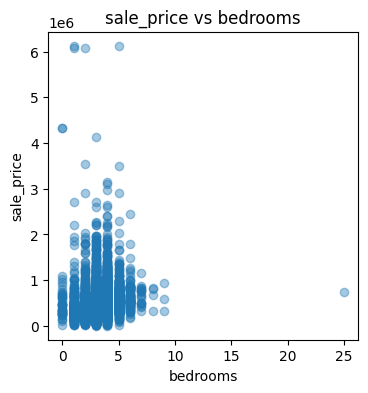

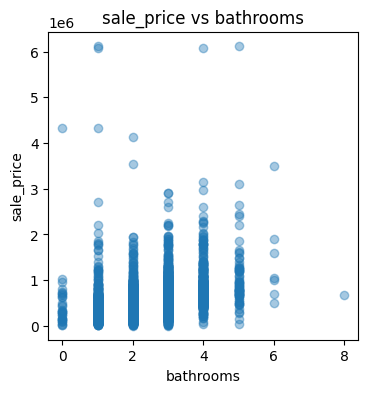

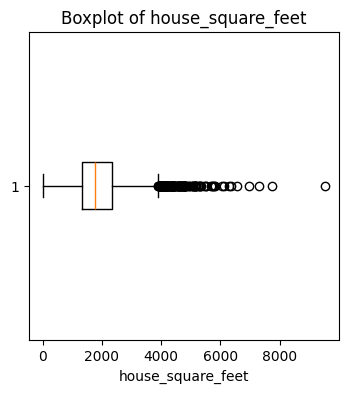

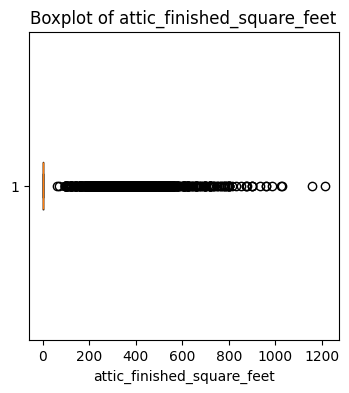

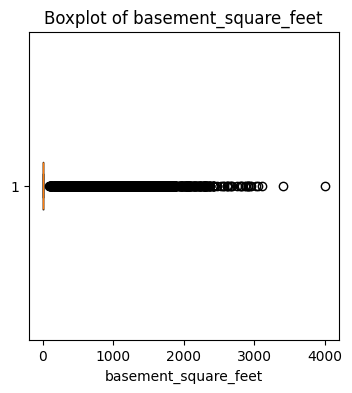

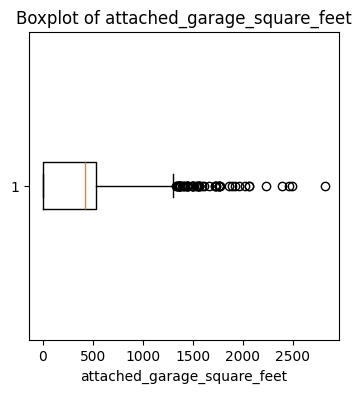

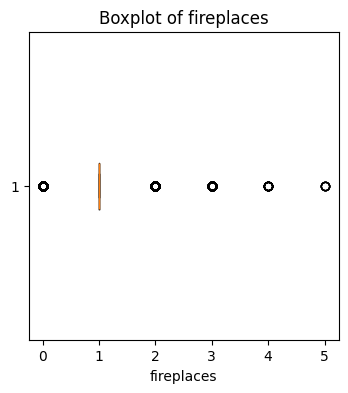

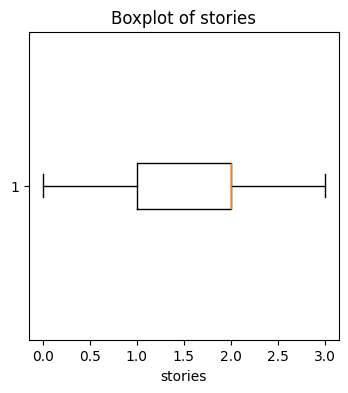

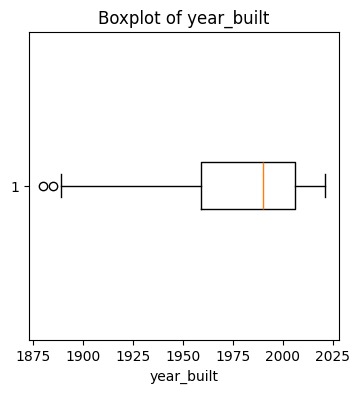

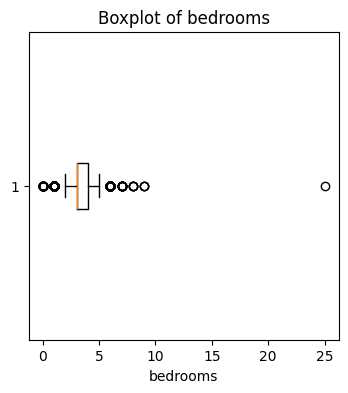

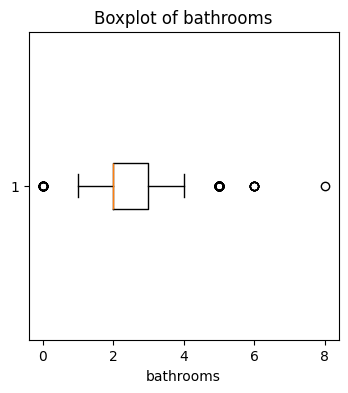

<Figure size 400x400 with 0 Axes>

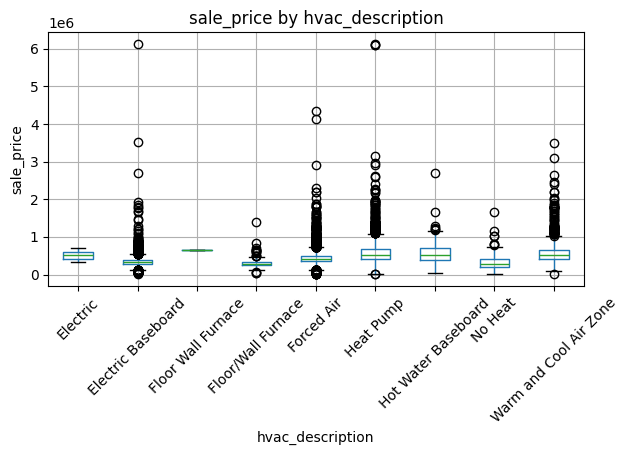

<Figure size 400x400 with 0 Axes>

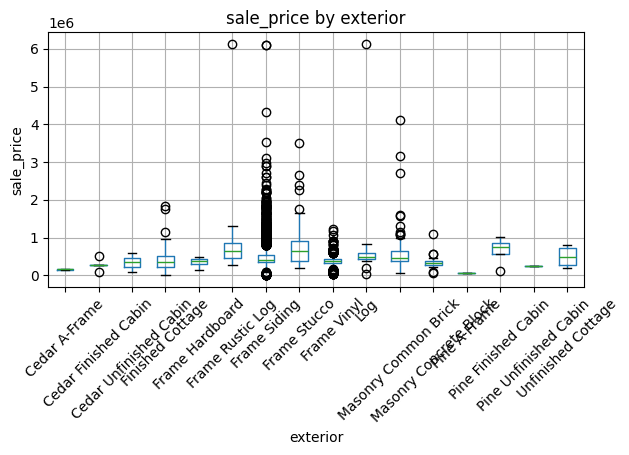

<Figure size 400x400 with 0 Axes>

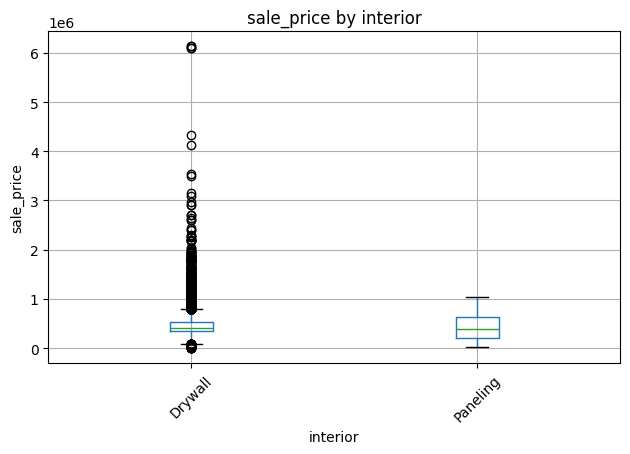

<Figure size 400x400 with 0 Axes>

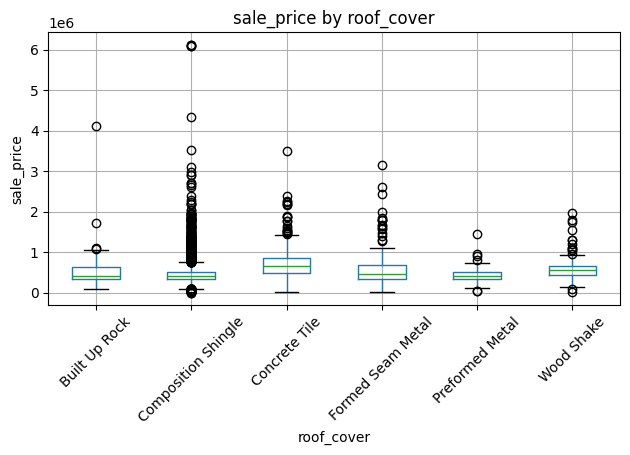

<Figure size 400x400 with 0 Axes>

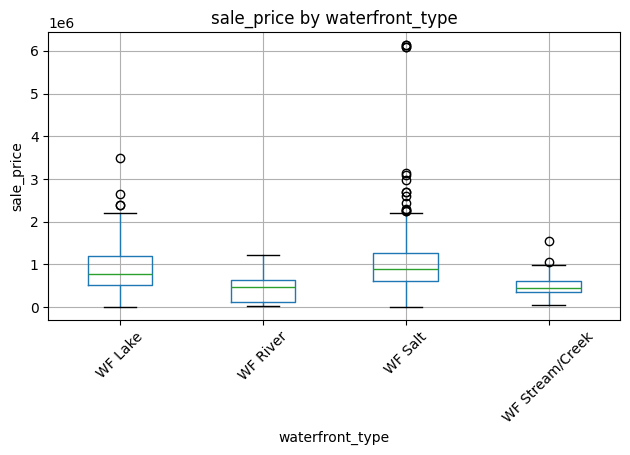

<Figure size 400x400 with 0 Axes>

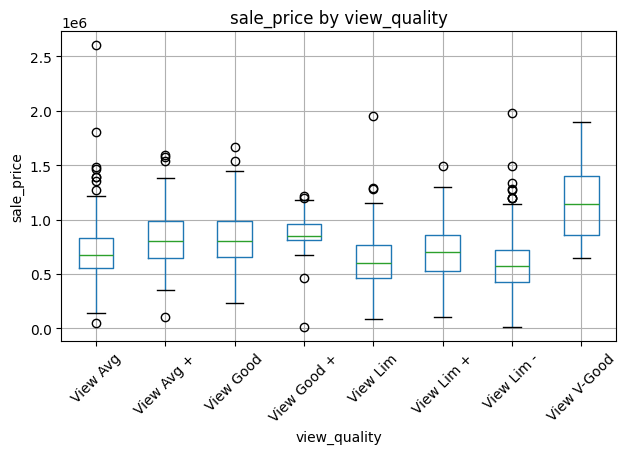

<Figure size 400x400 with 0 Axes>

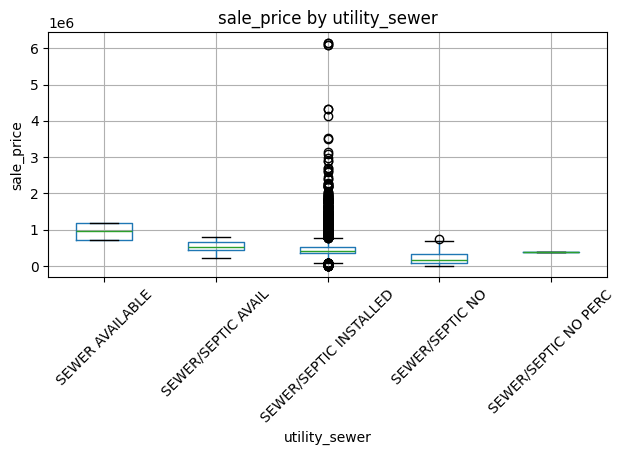

hvac_description
Forced Air                10382
Electric Baseboard         2668
Heat Pump                  2084
Warm and Cool Air Zone     1268
Floor/Wall Furnace          174
Hot Water Baseboard         146
No Heat                      82
NaN                           7
Electric                      2
Floor Wall Furnace            1
Name: count, dtype: int64
exterior
Frame Siding              14577
Frame Vinyl                1724
Masonry Common Brick        208
Frame Stucco                156
Masonry Concrete Block       43
Finished Cottage             41
Frame Rustic Log             21
Log                          12
Frame Hardboard              11
Cedar Finished Cabin          5
Unfinished Cottage            4
Pine Finished Cabin           4
Cedar A-Frame                 2
Pine Unfinished Cabin         2
Cedar Unfinished Cabin        2
NaN                           1
Pine A-Frame                  1
Name: count, dtype: int64
interior
Drywall     16777
Paneling       30
NaN          

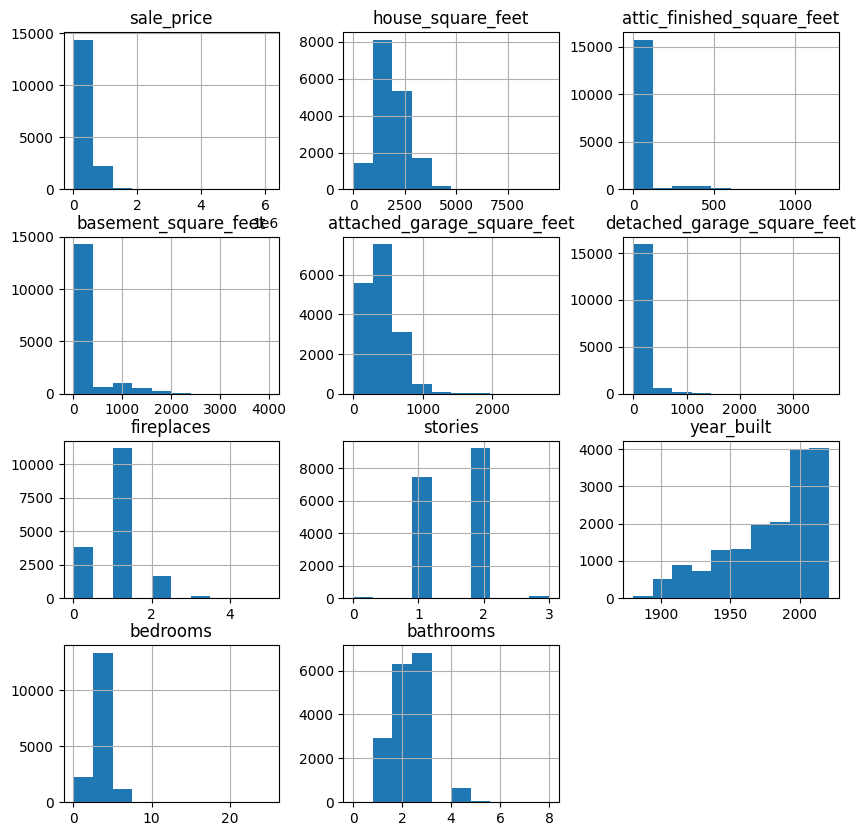

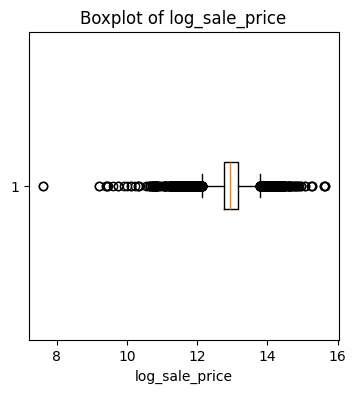

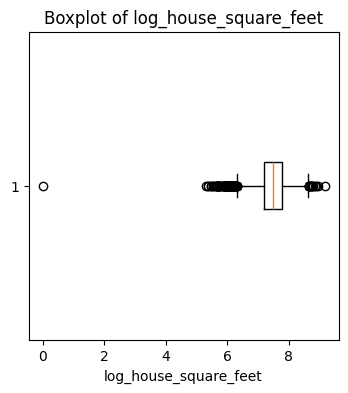

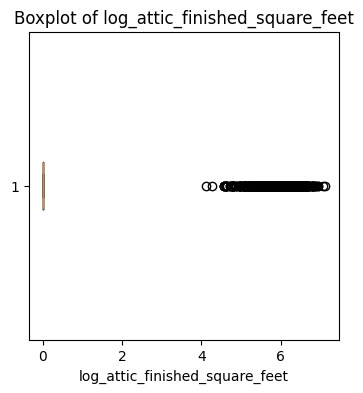

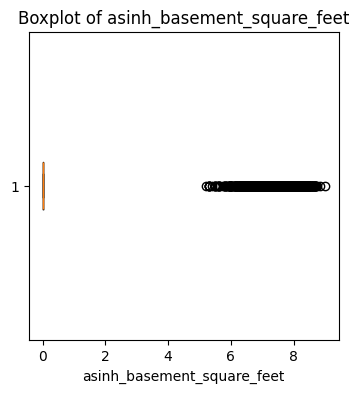

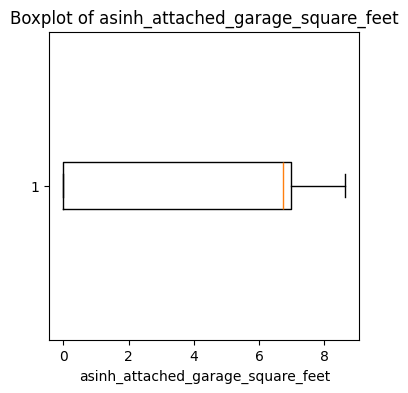

In [42]:
## Part 1 & 2: perform EDA and clean/transform data
df=pd.read_csv('/content/linear_models/lab/data/pierce_county_house_sales.csv')
# response:

# numerical variables:
# `sale_price`, `house_square_feet`, `attic_finished_square_feet`, `basement_square_feet`,
# `attached_garage_square_feet`, `fireplaces`, `stories`, `year_built`, `bedrooms`, `bathrooms`,
# define num vars (will use later)
num_vars = ['house_square_feet','attic_finished_square_feet',
    'basement_square_feet','attached_garage_square_feet','fireplaces',
    'stories','year_built','bedrooms','bathrooms']
# categorical variables:
# 'hvac_description`, `exterior`, `interior`, `roof_cover`, `waterfront_type`, `view_quality`,
# `utility_sewer`
# def'n cat vars
cat_vars = ['hvac_description','exterior','interior','roof_cover',
            'waterfront_type','view_quality','utility_sewer']

## EDA
print(df.head())
print(df.info())
print(df[num_vars].describe())
print(df[cat_vars].describe())
# summary stats on response
summary_stats = df['sale_price'].describe()
print(summary_stats)
print("\nMissing values:")
print(df[num_vars + cat_vars].isna().sum())

# scatterplots of y vs numeric/cont x's (check to see if all numeric vars are cont)
# also gives idea for outliers and skewness
resp = 'sale_price'
predict_num_vars = [var for var in num_vars if var != resp]
for var in predict_num_vars:
    plt.figure(figsize=(4, 4))
    plt.scatter(df[var], df[resp], alpha=0.4)
    plt.xlabel(var)
    plt.ylabel(resp)
    plt.title(f"{resp} vs {var}")
    plt.show()

# contin vs categor varis: boxplots
for var in num_vars:
    plt.figure(figsize=(4, 4))
    plt.boxplot(df[var].dropna(), vert=False)
    plt.title(f"Boxplot of {var}")
    plt.xlabel(var)
    plt.show()


for var in cat_vars:
    plt.figure(figsize=(4, 4))
    df.boxplot(column=resp, by=var, rot=45)
    plt.title(f"{resp} by {var}")
    plt.suptitle("")  # removes automatic pandas subtitle
    plt.xlabel(var)
    plt.ylabel(resp)
    plt.tight_layout()
    plt.show()
# histograms for each var
histograms = df.hist(figsize=(10, 10))



# for cat variables, check vals with na's
print(df['hvac_description'].value_counts(dropna=False))
print(df['exterior'].value_counts(dropna=False))
print(df['interior'].value_counts(dropna=False))
print(df['roof_cover'].value_counts(dropna=False))
print(df['utility_sewer'].value_counts(dropna=False))
# for waterfront and viewquality, make na's = no and value 0
print(df['waterfront_type'].value_counts())
print(df['view_quality'].value_counts())

# now make cat vars dummys (with intercept to avoid multicollin)
df = pd.get_dummies(df, columns=['hvac_description',
                                 'exterior','interior','roof_cover',
                                 'utility_sewer','waterfront_type',
                                 'view_quality'], drop_first=True)
# for numerical vars, get idea of any missing data
print(df['sale_price'].value_counts(dropna=False))
print(df['house_square_feet'].value_counts(dropna=False))
print(df['attic_finished_square_feet'].value_counts(dropna=False))
print(df['basement_square_feet'].value_counts(dropna=False))
print(df['attached_garage_square_feet'].value_counts(dropna=False))
print(df['fireplaces'].value_counts(dropna=False))
print(df['bathrooms'].value_counts(dropna=False))
print(df['stories'].value_counts(dropna=False))
print(df['year_built'].value_counts(dropna=False))
print(df['bedrooms'].value_counts(dropna=False))

# log-transformation for heavy tailed num vars
df['log_sale_price'] = np.log(df['sale_price'])
#df['log_attached_garage_square_feet'] = np.log(df['attached_garage_square_feet'])
df['log_house_square_feet'] = np.log(df['house_square_feet'])
# has 0's so log1p
df['log_attic_finished_square_feet'] = np.log1p(df['attic_finished_square_feet'])
#df['log_basement_square_feet'] = np.log(df['basement_square_feet'])
# arcsinh trans
df['asinh_attached_garage_square_feet'] = np.arcsinh(df['attached_garage_square_feet'])
df['asinh_basement_square_feet'] = np.arcsinh(df['basement_square_feet'])
#df['asinh_attic_finished_square_feet'] = np.arcsinh(df['attic_finished_square_feet'])
#df['asinh_house_square_feet'] = np.arcsinh(df['house_square_feet'])
#df['asinh_sale_price'] = np.arcsinh(df['sale_price'])
# check boxplots again
trans_num_vars = ['log_sale_price','log_house_square_feet',
                  'log_attic_finished_square_feet',
                  'asinh_basement_square_feet',
                'asinh_attached_garage_square_feet']
for var in trans_num_vars:
    plt.figure(figsize=(4, 4))
    plt.boxplot(df[var].dropna(), vert=False)
    plt.title(f"Boxplot of {var}")
    plt.xlabel(var)
    plt.show()



In [44]:
##  Part 3: Implement an 80/20 train-test split.
train1, test1 = train_test_split(df, test_size=0.2, random_state=123)

#Put the test data aside.

In [54]:
# Part 4: Build some simple linear models that include no transformations or interactions.
# build design matrics

# true simple linear models (one predictor)
X_train_dict = {}
X_test_dict = {}

for var in num_vars:
    X_train_dict[var] = train1[[var]]
    X_test_dict[var] = test1[[var]]
results = []

for var in num_vars:
    X_train = train1[[var]]
    X_test = test1[[var]]

    y_train = train1['sale_price']
    y_test = test1['sale_price']

    model = LinearRegression().fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    results.append({
        'variable': var,
        'train_r2': r2_score(y_train, pred_train),
        'test_r2': r2_score(y_test, pred_test),
        'train_rmse': np.sqrt(mean_squared_error(y_train, pred_train)),
        'test_rmse': np.sqrt(mean_squared_error(y_test, pred_test))
    })
results_df = pd.DataFrame(results).sort_values('test_rmse')
results_df

X_train2 = train1[['house_square_feet', 'year_built','bedrooms']]
X_test2 = test1[['house_square_feet', 'year_built','bedrooms']] # Corrected: use test1
# fit model
model2 = LinearRegression()
model2.fit(X_train2, y_train)
pred2 = model2.predict(X_test2)
r2_2 = r2_score(y_test, pred2)
rmse_2 = np.sqrt(mean_squared_error(y_test, pred2))
print("Test R^2:", r2_2)
print("Test RMSE:", rmse_2)

X_train3 = train1[['house_square_feet', 'bathrooms','fireplaces']]
X_test3 = test1[['house_square_feet', 'bathrooms','fireplaces']] # Corrected: use test1
# fit model
model3 = LinearRegression()
model3.fit(X_train3, y_train)
pred3 = model3.predict(X_test3) # Corrected: use X_test3 for prediction
r2_3 = r2_score(y_test, pred3) # Corrected: r3_score to r2_score and pred2 to pred3
rmse_3 = np.sqrt(mean_squared_error(y_test, pred3))
print("Test R^2:", r2_3)
print("Test RMSE:", rmse_3)


# build a full model
X_train4 = train1[['house_square_feet','attic_finished_square_feet',
    'basement_square_feet','attached_garage_square_feet','fireplaces',
    'stories','year_built','bedrooms','bathrooms']]
X_test4 = test1[['house_square_feet','attic_finished_square_feet',
    'basement_square_feet','attached_garage_square_feet','fireplaces',
    'stories','year_built','bedrooms','bathrooms']]
model4 = LinearRegression()
model4.fit(X_train4, y_train)
pred4 = model4.predict(X_test4)
r2_4 = r2_score(y_test, pred4)
rmse_4 = np.sqrt(mean_squared_error(y_test, pred4))
print("\nFull Model:")
print("Test R^2:", r2_4)
print("Test RMSE:", rmse_4)


X_train5= train1[['house_square_feet','stories','year_built','bathrooms']]
X_test5 = test1[['house_square_feet','stories','year_built','bathrooms']]
model5 = LinearRegression()
model5.fit(X_train5, y_train)
pred5 = model5.predict(X_test5)
r2_5 = r2_score(y_test, pred5)
rmse_5 = np.sqrt(mean_squared_error(y_test, pred5))
print("\nModel 5 Model:")
print("Test R^2:", r2_5)
print("Test RMSE:", rmse_5)

results_df = pd.DataFrame(results).sort_values('test_rmse')
results_df

Test R^2: 0.31565000465989124
Test RMSE: 179821.0609702395
Test R^2: 0.3059739281122693
Test RMSE: 181087.85069585498

Full Model:
Test R^2: 0.4123055924041017
Test RMSE: 166639.21092068797

Model 5 Model:
Test R^2: 0.32291772752475045
Test RMSE: 178863.67224417848


,variable,train_r2,test_r2,train_rmse,test_rmse
0,house_square_feet,0.273727,0.292555,204973.192178,182830.174725
8,bathrooms,0.169605,0.157167,219174.251355,199559.385064
4,fireplaces,0.120192,0.127001,225600.970592,203099.295774
3,attached_garage_square_feet,0.096081,0.098461,228671.444068,206392.421521
2,basement_square_feet,0.074791,0.061756,231348.630977,210551.953634
6,year_built,0.050493,0.061159,234366.827443,210618.899427
7,bedrooms,0.041593,0.044949,235462.664862,212429.485723
5,stories,0.027924,0.026237,237135.814182,214500.426903
1,attic_finished_square_feet,0.000626,-0.000812,240442.395512,217459.142585


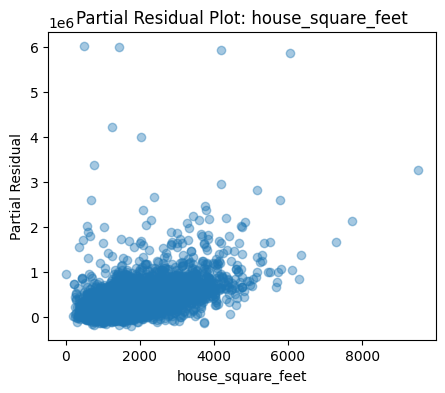

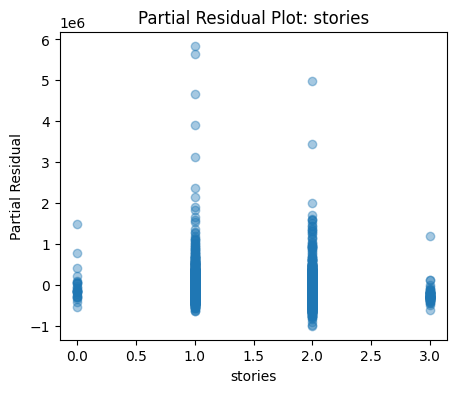

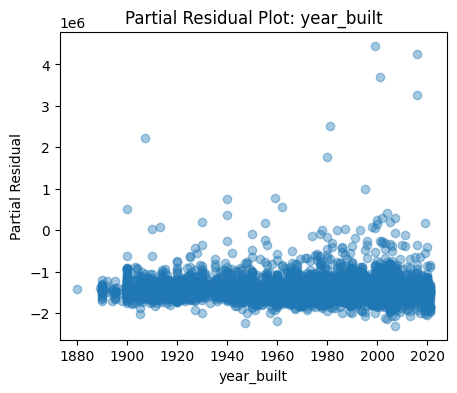

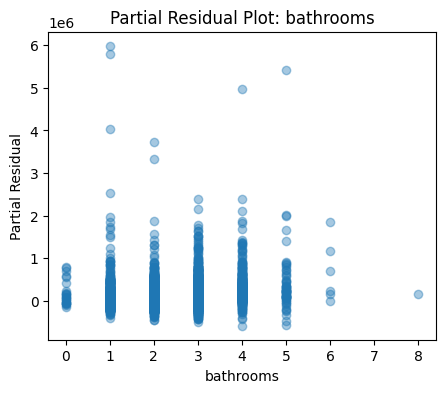

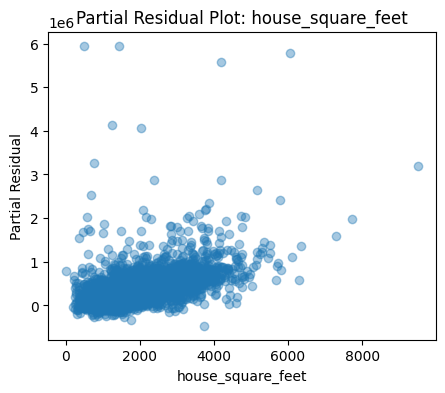

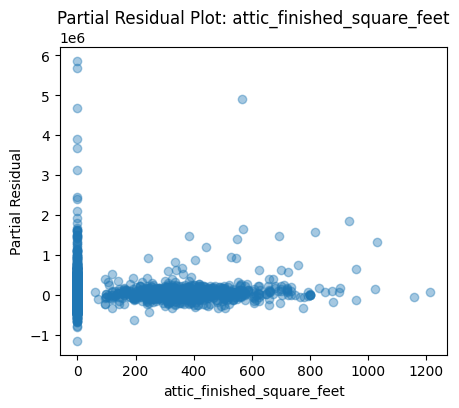

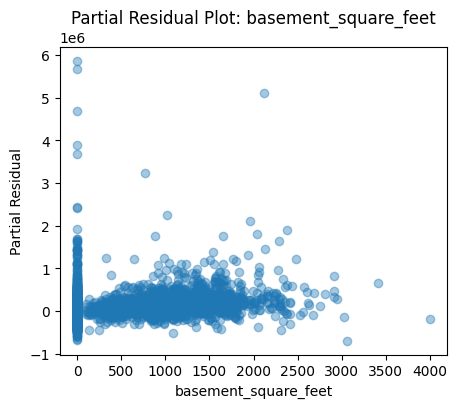

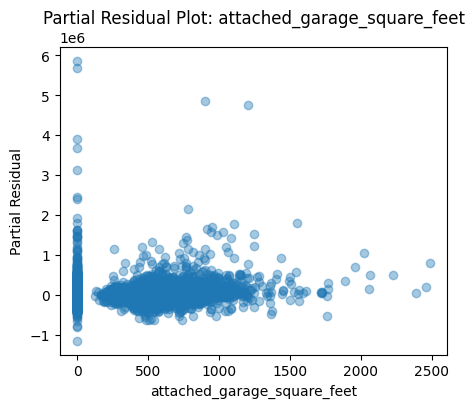

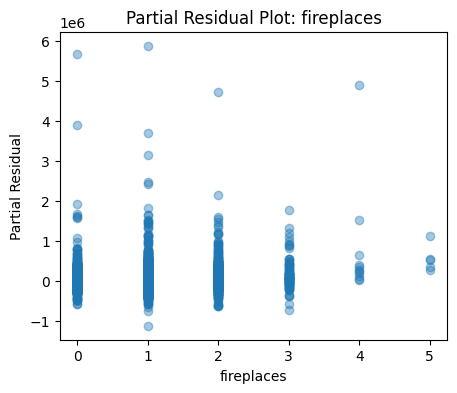

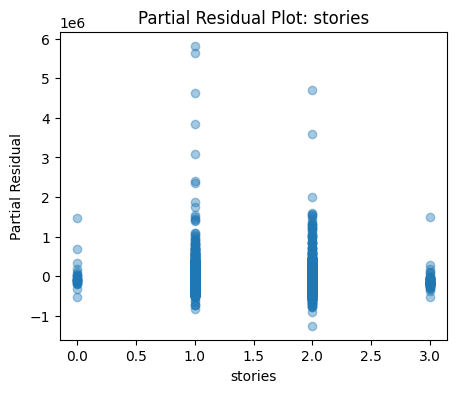

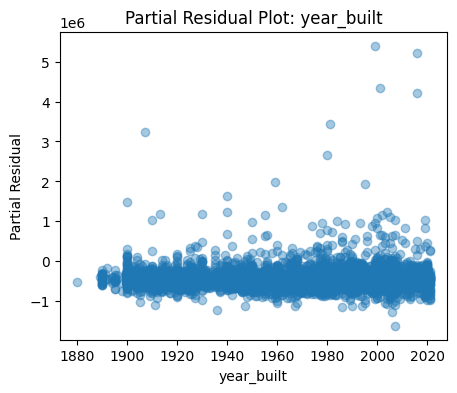

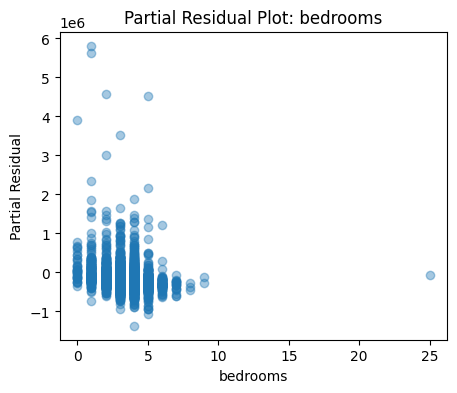

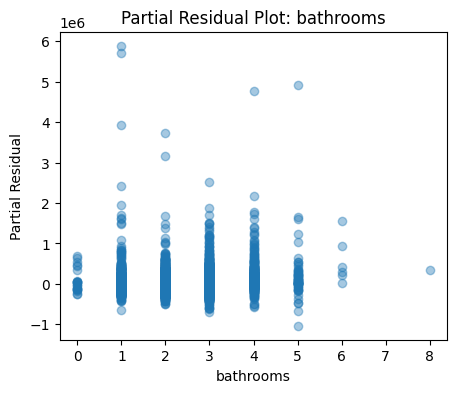

In [46]:
# Part 5: Make partial correlation plots for each of the numeric variables in your model.
# model 5 and model 4(the full model)

# Define X_train, y_train, and features for model5
X_train_model5 = train1[['house_square_feet','stories','year_built','bathrooms']]
y_train_model5 = train1['sale_price']
features_model5 = X_train_model5.columns

# Calculate residuals
residuals_model5 = y_train_model5 - model5.predict(X_train_model5)

for var in features_model5:
    # Get the coefficient for the current variable
    beta = model5.coef_[X_train_model5.columns.get_loc(var)]
    partial_resid = residuals_model5 + beta * X_train_model5[var]

    plt.figure(figsize=(5, 4))
    plt.scatter(X_train_model5[var], partial_resid, alpha=0.4)
    plt.title(f"Partial Residual Plot: {var}")
    plt.xlabel(var)
    plt.ylabel("Partial Residual")
    plt.show()

# full model
features_model4 = X_train4.columns

# Calculate residuals
residuals_model4 = y_train - model4.predict(X_train4)

for var in features_model4:
    # Get the coefficient for the current variable
    beta = model4.coef_[X_train4.columns.get_loc(var)]
    partial_resid = residuals_model4 + beta * X_train4[var]

    plt.figure(figsize=(5, 4))
    plt.scatter(X_train4[var], partial_resid, alpha=0.4)
    plt.title(f"Partial Residual Plot: {var}")
    plt.xlabel(var)
    plt.ylabel("Partial Residual")
    plt.show()

In [52]:
# Part 6: Include transformations and interactions of your variables, and build
# a more complex model that reflects your ideas about how the features of the
# asset determine its value.
# interactions
train1['sqft_bath'] = train1['log_house_square_feet'] * train1['bathrooms']
test1['sqft_bath'] = test1['log_house_square_feet'] * test1['bathrooms']

train1['sqft_bed'] = train1['log_house_square_feet'] * train1['bedrooms']
test1['sqft_bed'] = test1['log_house_square_feet'] * test1['bedrooms']

train1['bath_bed'] = train1['bathrooms'] * train1['bedrooms']
test1['bath_bed'] = test1['bathrooms'] * test1['bedrooms']
# make age
train1['age'] = 2026 - train1['year_built']
test1['age'] = 2026 - test1['year_built']
train1['sqft_age'] = train1['log_house_square_feet'] * train1['age']
test1['sqft_age'] = test1['log_house_square_feet'] * test1['age']
y_train2 = train1['log_sale_price']
y_test2 = test1['log_sale_price']

X_train7 = train1[['log_house_square_feet','asinh_basement_square_feet',
                 'log_attic_finished_square_feet','asinh_attached_garage_square_feet',
                 'bedrooms','bathrooms','fireplaces','age','sqft_bath','sqft_bed']]

X_test7 = test1[['log_house_square_feet','asinh_basement_square_feet',
                 'log_attic_finished_square_feet','asinh_attached_garage_square_feet',
                 'bedrooms','bathrooms','fireplaces','age','sqft_bath','sqft_bed']]
model7 = LinearRegression()
model7.fit(X_train7, y_train2)
pred_train7 = model7.predict(X_train7)
pred_test7 = model7.predict(X_test7)
print("Train R^2:", r2_score(y_train2, pred_train7))
print("Test R^2:", r2_score(y_test2, pred_test7))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train2, pred_train7)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test2, pred_test7)))
# Determine its RMSE and  R2  on the training and test sets.

# How does the more complex model your build compare to the simpler ones?

Test R^2: 0.32373077593438615
Test RMSE: 0.34731439973052963
Train R^2: 0.4034472681100437
Test R^2: 0.38207270220176315
Train RMSE: 0.33000932530015464
Test RMSE: 0.3319950957396569


**Part 7: Summarize findings from parts 1-6**


Part 1: what did eda find

In part 1, we found that some numeric variables such as `fireplaces` and `stories_built` are numeric, but discrete rather than continuous. I chose to leave these variables transformed, but they suggest non-linearity and may effect the overall linearity of the model. If the model struggles to satify the assumption for lienarty, then we may want to consider removing them. They will be left untransformed, however we could model them as categorical predictors if desired. Additionally, for variables like `house_square_feet` and `attic_finished_square_feet`, we are observing long right tails with many high value observations. This can be understood as large homes have large square feet values. These values are not outliers, however we should consider transformations (log or arcsinh) to reduction skew and improve linear regression assumptions.




Different transformations were evaluated for each variable. The inverse hyperbolic sine transformation was used for variables where it improved model performance, particularly for variables with many zero or small values. Log transformations were retained for variables where performance was similar due to their interpretability. This approach balances predictive accuracy and interpretability.

Part 2: Transformations on Variables
*   All categorical variables were one-hot-dummy encoded with an intercept (baseline). Further, more transformations were evaluated for each variable, especially the continuous variables. Log transformations were applied to the response, house square. The inverse hyperbolic sine transformation was applied for basement square feet and garage square feet because both variables show little-to-no change with a log transformation. I chose to use both types of transformation for interpretability purposes, balancing with prediction accuracy.

Part 4: building simple linear models without interactions and transformations.
Which of the models perform the best, reerence RMSE and $R^2$
*   I built true linear models (only one prediction variable) for each numeric variable. Additionally, I built a couple more models with different combinations of numeric predictors; and finally built a full model to compare the differing RMSE and $R^2$ values to. The model that performed the best was the on predicting sales price using house squared feet, stories, year built, and bathrooms. I chose this combination of variables because simple linear model of house squared feet had the highest $R^2$ and lowest RMSE, bathrooms had the 2nd highest and lowest respective values, and I was interested in the additional noise the stories variable may be able to capture. This model had a test $R^2=0.323, RMSE=178863.67$, compared to the full model's test $R^2=0.413, RMSE=166639.21$. Because $R^2$ does not account for predictors in the mode, therefore always increase with added terms, and a general concern for multicollinearity, I chose the predicting sales price using house squared feet, stories, year built, and bathrooms over the model with all numeric terms included.

Part 5: partial correlation plots for each numeric variable in model.
Note any significant non-linearities
*   The partial correlation plots for the chosen model help show the relationship between each predictor and the response, after accounting for the linear effects of the other predictors. Therefore this is a useful tool to check for any significant non-linearities. The `year_built` variable shows significant linearity and should be transformed or reevaluated (potentially outlier with large leverage present). The `house_square_feet` variable could also benefit from transformation, which was performed in part 2 and the log-house sqaured feet variable will be used in the next part.

The house sqaured feet partial correlation plot suggests a linear relationship, but there is some curvature on the right-end (larger houses). The partial correlation plot for stories shows that linearity is reasonable. Because of the discrete nature of the variablem this is more subjective, but 1, 2, and 3 story houses is to be expected. The plot for year built shows curvature suggesting that the pricing at old and new homes does not follow the same linear trend. This is a moderate violation of linearity. The bathrooms plot, similar to stories, is suggestive of a linear trend.

Part 6: Add transformations and interactions to build a more complex model.
How does the more complex model compare to the simpler ones?
*   As a consequence of the moderate violation of linearity for the `year_built` variable, I chose to define `age` and use it instead of year built. After testing different complex models, the best perfoming one I came with was $log(`salesprice`)=\beta_0+\beta_1log(house_square_feet)+\beta_2arcsinh(basement sq ft)+\beta_3log(attic finished sq ft)+\beta_4arcsinh(attached garage sq ft)+\beta_5bedrooms+\beta6(fireplaces)+\beta_7age+\beta_8(house sq ft* bath)+\beta_9(house sq ft* bed)$. While this is a quite complex model, I found increasing the prediction accuracy of the sale price to be a challenge, thus leading me to my chosen complex model. The complex model produced test $R^2=0.3821, RMSE = 0.332$. While the $R^2$ only increased by $~0.05$, the RMSE decreased by almost the full amount. This means the complex model explains a much greater proportion ofn variance in the log-transformed response, suggesting there was improvement in model fit under the complex model. It is difficult for us to compare the $R^2$ values as one is from `sales_price` and the other is `log(sales_price)`, however we are able to compare predictive perforamnce using

We might want to use stepwise regression, or AIC/BIC scores to help chose the covariates that explain the most information on sales price to avoid perfect multicollinearity.


The complex model outperformed the simple, chosen model. We saw an increase in $R^2$ from 0.323 to 0.3821, which indicates improved explained information in our response and is fair when compared to other house hedonic precing. While the RMSE values are not directly comparable due to being on different scales, the simple models RMSE = $178,863 suggest large prediction error. The complex model's RMSE = 0.332 can be interpretated as ~39% multiplicative error, which is more reasonable for housing data. Overall, the transformations and interaction terns in the complex model improved model performance by addressing issues such as skewness and heteroskedasticity. This lead to more reliable and accuracte predictions.

It would be worth exploring stepwise regression, or AIC/BIC scores to help chose the covariates that explain the most information on sales price to avoid perfect multicollinearity and prevent against unstable LS estimates.